In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
penguins_df = sns.load_dataset('penguins')
penguins_df.dropna(inplace=True)
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<Axes: >

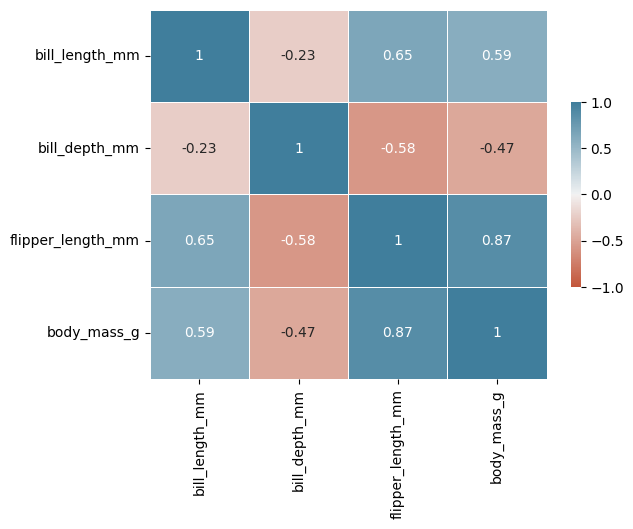

In [3]:
sns.heatmap(
    data=penguins_df.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# CODIFICAMOS LA VARIABLE SEX PARA PODER INCLUIRLA EN EL HEATMAP DE CORRELACIONES

## LABEL ENCODING

In [14]:
df_encoded = penguins_df.copy()

In [15]:
df_encoded['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [16]:
df_encoded['numeric_sex'] = df_encoded['sex'].map({'Female': 0, 'Male': 1})
df_encoded

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,numeric_sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,0


In [17]:
df_encoded['numeric_sex'] = df_encoded['sex'].astype('category').cat.codes
df_encoded

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,numeric_sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,0


<Axes: >

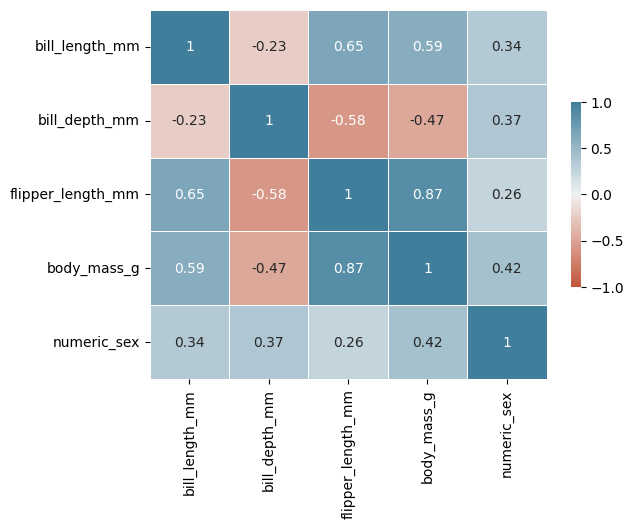

In [9]:
sns.heatmap(
    data=df_encoded.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# ONE HOT ENCODING

In [18]:
df_encoded = pd.get_dummies(df_encoded,columns=['island','species'],prefix='numeric', dtype=int)
df_encoded

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,numeric_sex,numeric_Biscoe,numeric_Dream,numeric_Torgersen,numeric_Adelie,numeric_Chinstrap,numeric_Gentoo
0,39.1,18.7,181.0,3750.0,Male,1,0,0,1,1,0,0
1,39.5,17.4,186.0,3800.0,Female,0,0,0,1,1,0,0
2,40.3,18.0,195.0,3250.0,Female,0,0,0,1,1,0,0
4,36.7,19.3,193.0,3450.0,Female,0,0,0,1,1,0,0
5,39.3,20.6,190.0,3650.0,Male,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,Female,0,1,0,0,0,0,1
340,46.8,14.3,215.0,4850.0,Female,0,1,0,0,0,0,1
341,50.4,15.7,222.0,5750.0,Male,1,1,0,0,0,0,1
342,45.2,14.8,212.0,5200.0,Female,0,1,0,0,0,0,1


In [19]:
df_encoded.dtypes

,0
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
numeric_sex,int8
numeric_Biscoe,int64
numeric_Dream,int64
numeric_Torgersen,int64
numeric_Adelie,int64


<Axes: >

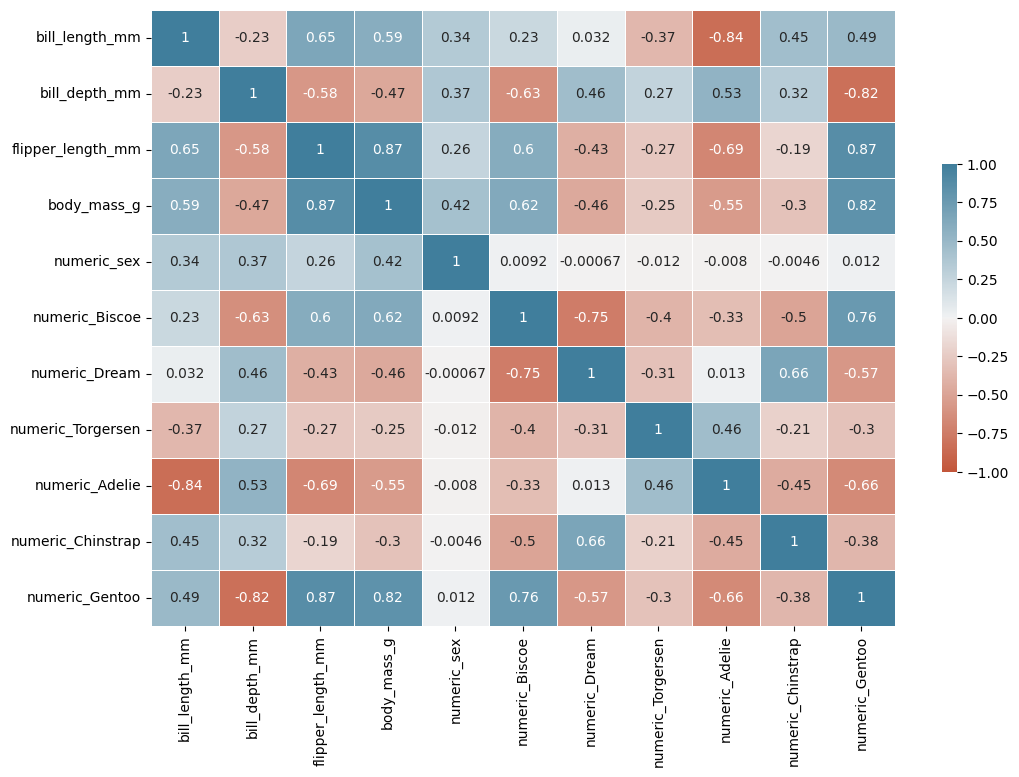

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    data=df_encoded.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# CLUSTERMAP

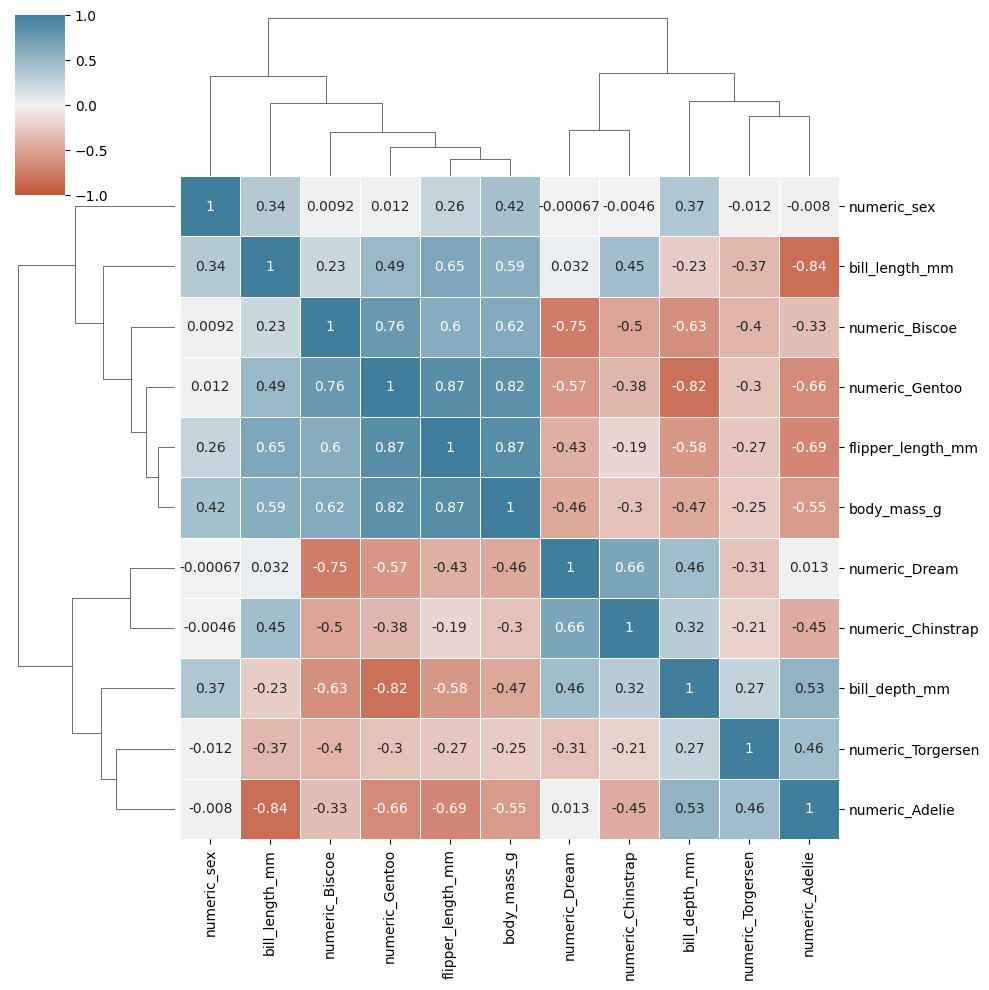

In [22]:

sns.clustermap(
    data=df_encoded.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# SUPONIENDO QUE LA VARIABLE DEPENDIENTE SEA EL SEXO, DETERMINAMOS LA VARIABLES CON MAYOR CORRELACIÓN PARA ESTE VARIABLE

<Axes: >

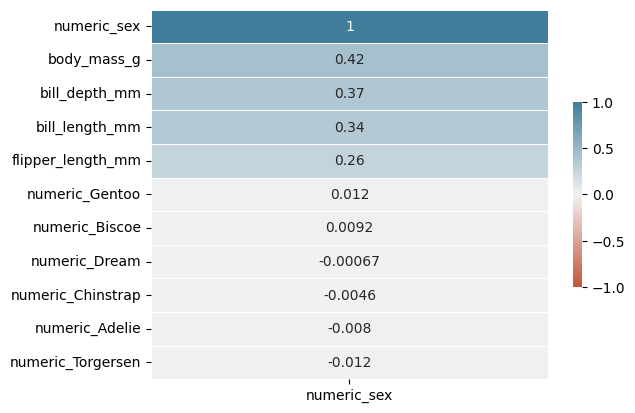

In [23]:
corr_matrix = df_encoded.corr(numeric_only=True)
corr_age = corr_matrix[['numeric_sex']].sort_values(by='numeric_sex',ascending=False)
sns.heatmap(
    data=corr_age,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)